# Analysis of $\gamma$ Doradus stars

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import os
import sys
import glob
import scipy
import numpy as np
import pandas as pd
import scipy as sp
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.optimize import curve_fit
from matplotlib import patches
from matplotlib.ticker import FuncFormatter

# PlatoSim extra
import natsort
from astropy import units as u
from astropy.coordinates import SkyCoord
from pathlib import Path
from tqdm import tqdm 

# PlatoSim libraries
import platosim.plot       as pt
import platosim.noise      as ns
import platosim.utilities  as ut
import platosim.statistics as st
from platosim.simfile      import SimFile
from platosim.simulation   import Simulation
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_paper
setup_paper()

import warnings
warnings.simplefilter("ignore")

In [3]:
# Define paths used throughout
fdir = '/lhome/nicholas/Nextcloud/paperMOCKA/figures'

---
## Test to compare input and output
---

In [53]:
# Load star results
star = f'{1}'.zfill(9)
path = '/lhome/nicholas/software/workdir/mocka_affogato'
dp = pd.read_feather(f'{path}/varsource/{star}/varsource_001_parameters.ftr')
df = pd.read_feather(f'{path}/varsource/{star}/varsource_001_pulsations.ftr')
dm = pd.read_feather(f'{path}/test_final/modes/modes_{star}.ftr')

# Correct for gamma factor
df.ampl *= 2.2

# Convert dmag to ppm
df.ampl = (1 - ut.fromMagToFlux(df.ampl)) * 1e6

# Fetch input frequencies in pettern
f_i = 1 / np.array([dp.DeltaP0_day * ((1 + dp.slope)**i - 1)/dp.slope + dp.P0_day for i in range(dp.N_modes[0])])

# Get pattern
dex_df = np.array([ut.findNearestIndex(df.freq, f_i[i]) for i in range(dp.N_modes[0])])
dex_dm = np.array([ut.findNearestIndex(dm.freq, f_i[i]) for i in range(dp.N_modes[0])])
df0 = df.loc[dex_df].reset_index(drop=True)
dm0 = dm.loc[dex_dm].reset_index(drop=True)

# O-C plot
f_oc = df0.freq.to_numpy() - dm0.freq.to_numpy()
A_oc = df0.ampl.to_numpy() - dm0.ampl.to_numpy()

dm1 = dm[dm.passed_snr]

# Remove matches above 0.01 c/d in the OC diagram
x = 0.0005
dex = np.where((np.abs(f_oc) > x))[0]
dm0 = dm0.drop(index=dex)
f0_oc = np.delete(f_oc, dex)
A0_oc = np.delete(A_oc, dex)

print(f'Stellar magnitude  : {dp.Pmag[0]:.4f} mag')
print(f'Limiting amplitude : {dm.ampl.min():.4f} ppm')
print(f'Number of modes    : {dm0.shape[0]}/{dp.N_modes[0]}')
print(f'RMS O-C amplitude  : {ut.rootMeanSquare(A0_oc):.4f} ppm')
print(f'RMS O-C frequency  : {ut.rootMeanSquare(f0_oc)*1e6:.4f} ppm/d')

Stellar magnitude  : 13.9368 mag
Limiting amplitude : 43.9185 ppm
Number of modes    : 13/16
RMS O-C amplitude  : 481.3366 ppm
RMS O-C frequency  : 142.3186 ppm/d


<IPython.core.display.Javascript object>


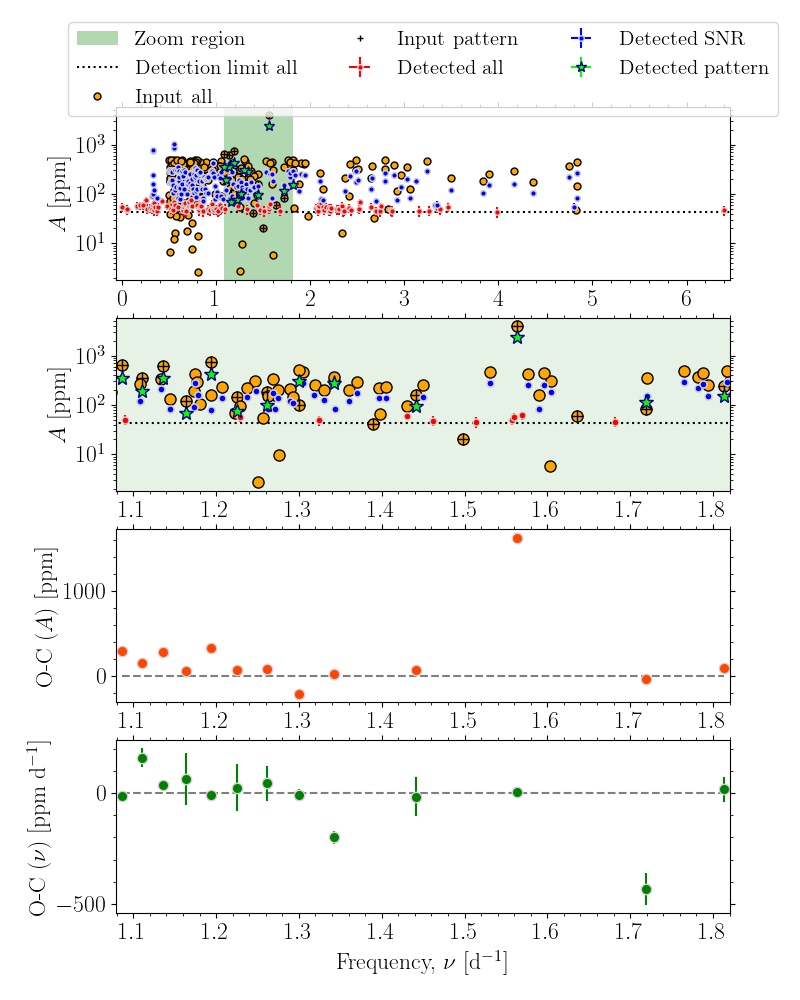

In [54]:
fig, ax = plt.subplots(4, 1, figsize=(8,10))

xlim0 = pt.getAxesMinMax(x=dm.freq.to_numpy(),  percentage=1)
xlim1 = pt.getAxesMinMax(x=dm0.freq.to_numpy(), percentage=1)

ax[0].axvspan(df0.freq.min(), df0.freq.max(), color='g', alpha=0.3, lw=0, label='Zoom region')
# ax[0].axvline(x=1/(ut.quarter()), ls='--', c='m', label='Quarter')
# ax[0].axvline(x=1/(ut.quarter()/3), ls=':', c='m', label='Mask-update')
ax[0].axhline(y=dm.ampl.min(), xmin=xlim0[1], xmax=xlim0[0], ls=':', c='k', label='Detection limit all')
ax[0].plot(df.freq,  df.ampl,  'o', ms=5, c='orange', mec='k', label='Input all')
ax[0].plot(df0.freq, df0.ampl, '+', ms=5, c='k', label='Input pattern')
ax[0].errorbar(dm.freq,  dm.ampl,  xerr=dm.freq_err,  yerr=dm.ampl_err,  fmt=".", ms=8, mec='lightgray', color="red",  label='Detected all')
ax[0].errorbar(dm1.freq, dm1.ampl, xerr=dm1.freq_err, yerr=dm1.ampl_err, fmt=".", ms=8, mec='lightgray', color="blue", label='Detected SNR')
ax[0].errorbar(dm0.freq, dm0.ampl, xerr=dm0.freq_err, yerr=dm0.ampl_err, fmt="*", ms=8, mec='navy', color="lime", label='Detected pattern')
ax[0].legend(loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.55), fontsize=15)
ax[0].set_ylabel(r'$A$ [ppm]')
ax[0].set_yscale('log')
ax[0].set_xlim(xlim0)

ax[1].axvspan(xlim1[0], xlim1[1], color='g', alpha=0.1, lw=0)
ax[1].axhline(y=dm.ampl.min(), xmin=xlim0[0], xmax=xlim0[1], ls=':', c='k')
ax[1].plot(df.freq,  df.ampl,  'o', ms=8, c='orange', mec='k')
ax[1].plot(df0.freq, df0.ampl, '+', ms=8, c='k')
ax[1].errorbar(dm.freq,  dm.ampl,  xerr=dm.freq_err,  yerr=dm.ampl_err,  fmt=".", ms=10, mec='lightgray', color="red")
ax[1].errorbar(dm1.freq, dm1.ampl, xerr=dm1.freq_err, yerr=dm1.ampl_err, fmt=".", ms=10, mec='lightgray', color="blue")
ax[1].errorbar(dm0.freq, dm0.ampl, xerr=dm0.freq_err, yerr=dm0.ampl_err, fmt="*", ms=10, mec='navy', color="lime")
ax[1].set_ylabel(r'$A$ [ppm]')
ax[1].set_yscale('log')
ax[1].set_xlim(xlim1[1], xlim1[0])

ax[2].plot([df0.freq.min(), df0.freq.max()], [0, 0], 'k--', alpha=0.5)
ax[2].errorbar(dm0.freq, A0_oc, xerr=None, yerr=dm0.ampl_err, fmt=".", ms=15, mec='lightgray', color="orangered")
ax[2].set_ylabel(r'O-C ($A$) [ppm]')
ax[2].set_xlim(xlim1[1], xlim1[0])

ax[3].plot([df0.freq.min(), df0.freq.max()], [0, 0], 'k--', alpha=0.5)
ax[3].errorbar(dm0.freq, f0_oc*1e6, xerr=None, yerr=dm0.freq_err*1e6, fmt=".", ms=15, mec='lightgray', color="g")
ax[3].set_xlabel(r'Frequency, $\nu$ [d$^{-1}$]')
ax[3].set_ylabel(r'O-C ($\nu$) [ppm d$^{-1}$]')
ax[3].set_xlim(xlim1[1], xlim1[0])

plt.tight_layout(h_pad=0.1);
# fig.savefig(f'{fdir}/FrequencyModelComparison_test0.png', bbox_inches='tight', dpi=200)

In [ ]:
# fig, ax = plt.subplots(3, 1, figsize=(8,8))

# xlim0 = pt.getAxesMinMax(x=dm.freq.to_numpy(),  percentage=1)
# xlim1 = pt.getAxesMinMax(x=dm0.freq.to_numpy(), percentage=1)

# ax[0].axvspan(df0.freq.min(), df0.freq.max(), color='green', alpha=0.3, lw=0, label='Zoom region')
# ax[0].axhline(y=dm.ampl.min(), xmin=xlim0[1], xmax=xlim0[0], ls=':', c='k', label='Detection limit')
# ax[0].plot(df.freq,  df.ampl,  'o', ms=5, c='orange', mec='k', label='Input all')
# ax[0].plot(df0.freq, df0.ampl, '+', ms=5, c='k', label='Input pattern')
# ax[0].errorbar(dm.freq,  dm.ampl,  xerr=dm.freq_err,  yerr=dm.ampl_err,  fmt=".", ms=8, mec='lightgray', color="b", label='Detected all')
# ax[0].errorbar(dm0.freq, dm0.ampl, xerr=dm0.freq_err, yerr=dm0.ampl_err, fmt=".", ms=8, mec='lightgray', color="deeppink", label='Detected pattern')
# ax[0].legend(loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.55), fontsize=15)
# ax[0].set_ylabel(r'$A$ [ppm]')
# ax[0].set_yscale('log')
# ax[0].set_xlim(xlim0)

# ax[1].axvspan(xlim1[0], xlim1[1], color='green', alpha=0.1, lw=0)
# ax[1].axhline(y=dm.ampl.min(), xmin=xlim0[0], xmax=xlim0[1], ls=':', c='k')
# ax[1].plot(df.freq,  df.ampl,  'o', ms=8, c='orange', mec='k')
# ax[1].plot(df0.freq, df0.ampl, '+', ms=8, c='k')
# ax[1].errorbar(dm.freq,  dm.ampl,  xerr=dm.freq_err,  yerr=dm.ampl_err,  fmt=".", ms=10, mec='lightgray', color="b")
# ax[1].errorbar(dm0.freq, dm0.ampl, xerr=dm0.freq_err, yerr=dm0.ampl_err, fmt=".", ms=10, mec='lightgray', color="deeppink")
# ax[1].set_ylabel(r'$A$ [ppm]')
# ax[1].set_yscale('log')
# ax[1].set_xlim(xlim1[1], xlim1[0])

# ax[2].plot([df0.freq.min(), df0.freq.max()], [0, 0], 'k--', alpha=0.5)
# ax[2].errorbar(dm0.freq, f0_oc*1e4, xerr=None, yerr=dm0.freq_err*1e4, fmt=".", ms=15, mec='lightgray', color="g")
# ax[2].set_xlabel(r'Frequency, $\nu$ [d$^{-1}$]')
# ax[2].set_ylabel(r'O-C ($\nu$) [ppm d$^{-1}$]')
# ax[2].set_xlim(xlim1[1], xlim1[0])

# plt.tight_layout(h_pad=0.1);
# fig.savefig(f'{fdir}/FrequencyModelComparison_test0.png', bbox_inches='tight', dpi=200)

---
## Distribution of input modes
---

In [60]:
path = Path('/lhome/nicholas/software/workdir/mocka/varsource/gDor')
folders_parameters = natsort.natsorted(glob.glob(f'{path}/parameters/*'))
folders_pulsations = natsort.natsorted(glob.glob(f'{path}/pulsations/*'))

In [72]:
# Load all pulsation modes
N = len(folders_parameters)
N_modes = np.zeros(N)
dm = pd.DataFrame()
for m,i,j in zip(range(N), folders_parameters, tqdm(folders_pulsations, bar_format=ut.tqdmBar())):    
    
    # Parameter file
    df_parameters = pd.read_feather(i)
    n = int(df_parameters.N_modes)
    N_modes[m] = n
    
    # Pulsation file
    df_pulsations = pd.read_feather(j)
    
    # Save only pulsation modes
    dm = pd.concat([dm, df_pulsations[:n]])

100%|█████████████████████████████████████████████████▉| 5999/6000 [00:19<00:00,


In [219]:
dm

,freq,ampl,phase
0,1.812871,0.000120,0.575639
1,1.718538,0.000040,3.970952
2,1.636021,0.000030,1.978801
3,1.563265,0.001966,1.730382
4,1.498664,0.000010,3.710715
...,...,...,...
10,1.913774,0.000133,1.741327
11,1.888669,0.000266,0.487423
12,1.865132,0.000123,4.698439
13,1.843038,0.000348,2.035501


<IPython.core.display.Javascript object>


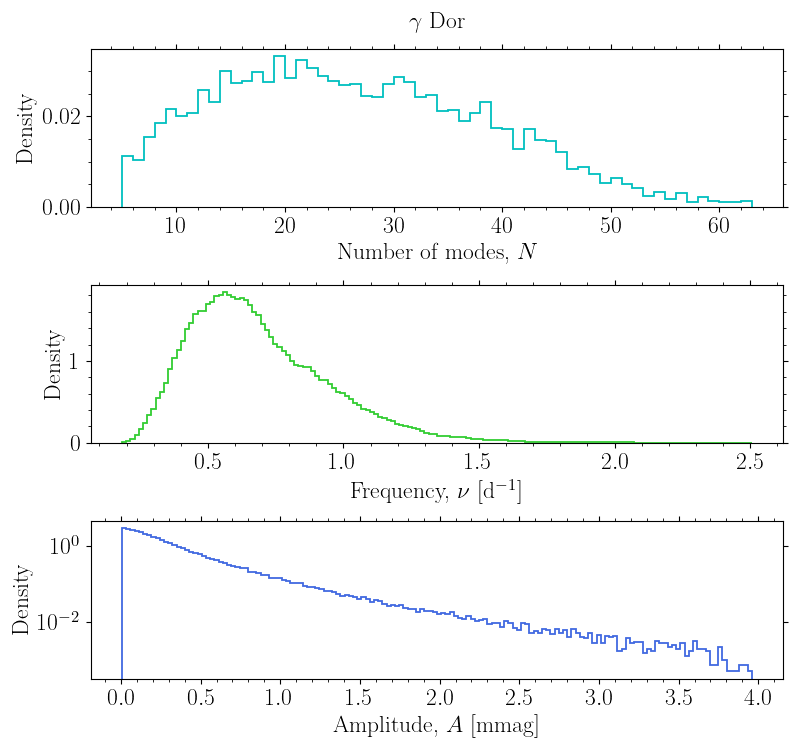

In [98]:
# Histograms
panels = 3
fig, ax = plt.subplots(panels, 1, figsize=(8, 2.5*panels))

h = ax[0].hist(N_modes, bins=int(np.max(N_modes)-5), histtype='step', density=True, ec='c', lw=1.3)
ax[0].set_xlabel(r'Number of modes, $N$')

h = ax[1].hist(1/dm.freq, bins=150, histtype='step', density=True, ec='limegreen', lw=1.3)
ax[1].set_xlabel(r'Frequency, $\nu$ [d$^{-1}$]')
ax[1].set_ylabel('Density')

ax[2].hist(dm.ampl*1e3, bins=150, histtype='step', density=True, ec='royalblue', lw=1.3)
ax[2].set_xlabel(r'Amplitude, $A$ [mmag]')
# ax[1].set_xscale('log')
ax[2].set_yscale('log')
# ax[2].set_xlim(0, 0.02)
# ax[2].set_ylim(0.1, 1e4)

ax[0].set_title(r'$\gamma$ Dor', pad=15)
for i in range(panels): 
    ax[i].set_ylabel('Density')
#     ax[i].legend(loc='best')
plt.tight_layout(pad=0.5);

# Save figure
# fig.savefig(f'{fdir}/hist_parameters_dsct.png', bbox_inches='tight', dpi=200)

---
## Detection rates
---

In [104]:
path = Path('/lhome/nicholas/software/workdir/mocka/varsource/gDor')

batch = 'affogato'
files_table = natsort.natsorted(glob.glob(f'{path}/finals_{batch}/table/*'))
files_modes = natsort.natsorted(glob.glob(f'{path}/finals_{batch}/final/*'))

dv = pd.read_feather(files_table[0])

dv.SPR.mean()

0.2370989391299899

In [158]:
def match_modes(file_parameters, file_pulsations, file_modes, file_table):

    # Load files from for varsource
    dp = pd.read_feather(file_parameters)
    do = pd.read_feather(file_pulsations)
    
    # Load results from simulations
    dm = pd.read_feather(file_modes)
    dt = pd.read_feather(file_table)

    # Correct for gamma factor
#     df.ampl *= 2.2

    # Convert amplitudes [dmag -> ppm]
    do.ampl = (1 - ut.fromMagToFlux(do.ampl)) * 1e6

    # Fetch input frequencies in pettern
    f_i = 1 / np.array([dp.DeltaP0_day * ((1 + dp.slope)**i - 1)/dp.slope + dp.P0_day 
                        for i in range(dp.N_modes[0])])

    # Find indices of matching frequencies
    dex_do = np.array([ut.findNearestIndex(do.freq, f_i[i]) for i in range(dp.N_modes[0])])
    dex_dm = np.array([ut.findNearestIndex(dm.freq, f_i[i]) for i in range(dp.N_modes[0])])
    
    # Get pattern passed BIC criterion
    do_bic = do.loc[dex_do].reset_index(drop=True)
    dm_bic = dm.loc[dex_dm].reset_index(drop=True)

    # Get pattern passed SNR criterion
    do_snr = do_bic[dm_bic.passed_snr].reset_index(drop=True)
    dm_snr = dm_bic[dm_bic.passed_snr].reset_index(drop=True)
    
    # Compute O-C values [ppm]
    f_oc_bic = (do_bic.freq.to_numpy() - dm_bic.freq.to_numpy())
    f_oc_snr = (do_snr.freq.to_numpy() - dm_snr.freq.to_numpy())
    A_oc_bic = (do_bic.ampl.to_numpy() - dm_bic.ampl.to_numpy())
    A_oc_snr = (do_snr.ampl.to_numpy() - dm_snr.ampl.to_numpy())

    # Remove matches above O-C threshold
    x = 0.0005
    dex_bic = np.where((np.abs(f_oc_bic) > x))[0]
    dex_snr = np.where((np.abs(f_oc_snr) > x))[0]
#     print(dex_snr)
#     print(dm_snr)
    dm_bic = dm_bic.drop(index=dex_bic)
    dm_snr = dm_snr.drop(index=dex_snr)
    
    f_oc_bic = np.delete(f_oc_bic, dex_bic) * 1e6
    f_oc_snr = np.delete(f_oc_snr, dex_snr) * 1e6
    A_oc_bic = np.delete(A_oc_bic, dex_bic)
    A_oc_snr = np.delete(A_oc_snr, dex_snr)

    # Store values into data frame
    df_oc_bic = pd.DataFrame({'freq':dm_bic.freq, 'ampl':dm_bic.ampl,
                              'freq_oc':f_oc_bic, 'ampl_oc':A_oc_bic})
    df_oc_snr = pd.DataFrame({'freq':dm_snr.freq, 'ampl':dm_snr.ampl,
                              'freq_oc':f_oc_snr, 'ampl_oc':A_oc_snr})
    
    # Store in data frame
    dx = pd.DataFrame({'Pmag': dp.Pmag,
                       'ncam': dt.shape[0],
                       'SPR': dt.SPR.mean(),
                       'A_limit': dm_bic.ampl.min(),
                       'N_input': dp.N_modes[0],
                       'N_bic': dm_bic.shape[0],
                       'N_snr': dm_snr.shape[0],
                       'f_rms_bic': ut.rootMeanSquare(f_oc_bic),
                       'f_rms_snr': ut.rootMeanSquare(f_oc_snr),
                       'A_rms_bic': ut.rootMeanSquare(A_oc_bic),
                       'A_rms_snr': ut.rootMeanSquare(A_oc_snr),
                      })
    
    return dx, df_oc_bic, df_oc_snr 

In [159]:
def fetch_all_modes(batch='affogato'):
    
    files_parameters = natsort.natsorted(glob.glob(f'{path}/parameters/*'))
    files_pulsations = natsort.natsorted(glob.glob(f'{path}/pulsations/*'))
    files_modes = natsort.natsorted(glob.glob(f'{path}/finals_{batch}/modes/*'))
    files_table = natsort.natsorted(glob.glob(f'{path}/finals_{batch}/table/*'))
    
    dx = pd.DataFrame()
    df_bic = pd.DataFrame()
    df_snr = pd.DataFrame()
    for i in tqdm(range(len(files_modes)), bar_format=ut.tqdmBar()):    

        dx0, df0_bic, df0_snr = match_modes(files_parameters[i], 
                                             files_pulsations[i], 
                                             files_modes[i], 
                                             files_table[i])
        dx = pd.concat([dx, dx0])
        df_bic = pd.concat([df_bic, df0_bic])
        df_snr = pd.concat([df_snr, df0_snr])
    
    return dx, df_bic, df_snr

In [160]:
dx, df_bic, df_snr = fetch_all_modes(batch='affogato')

100%|██████████████████████████████████████████████████| 5576/5576 [02:04<00:00,


In [307]:
dx

,Pmag,ncam,SPR,A_limit,N_input,N_bic,N_snr,f_rms_bic,f_rms_snr,A_rms_bic,A_rms_snr
0,13.936833,48,0.237099,69.492107,16,13,12,142.318578,146.945071,176.625406,183.791569
0,11.653350,48,0.012636,100.939423,13,13,13,62.222713,62.222713,932.962042,932.962042
0,10.915871,48,0.110751,24.756166,14,14,14,24.969989,24.969989,167.484357,167.484357
0,11.040159,48,0.009698,17.846253,40,40,39,49.185739,32.829419,322.318999,326.420967
0,12.522381,48,0.011275,50.687950,37,35,35,79.709035,79.709035,654.023346,654.023346
...,...,...,...,...,...,...,...,...,...,...,...
0,12.315666,192,0.000000,51.273929,20,19,19,110.786652,110.786652,328.287498,328.287498
0,11.721022,192,0.173305,11.683579,8,8,7,47.365968,16.514202,99.251125,106.099979
0,9.312771,192,0.775785,NaN,7,0,0,NaN,NaN,NaN,NaN
0,15.545957,192,0.000000,49.281538,22,22,22,43.379862,43.379862,742.919242,742.919242


In [300]:
N = 62

count_input, bin_input = np.histogram(dx.N_input, bins=N, range=(0, N))
count_bic, bin_bic     = np.histogram(dx.N_bic,   bins=N, range=(0, N))
count_snr, bin_snr     = np.histogram(dx.N_snr,   bins=N, range=(0, N))

N_oc_bic = count_bic - count_input
N_oc_snr = count_snr - count_input

<IPython.core.display.Javascript object>


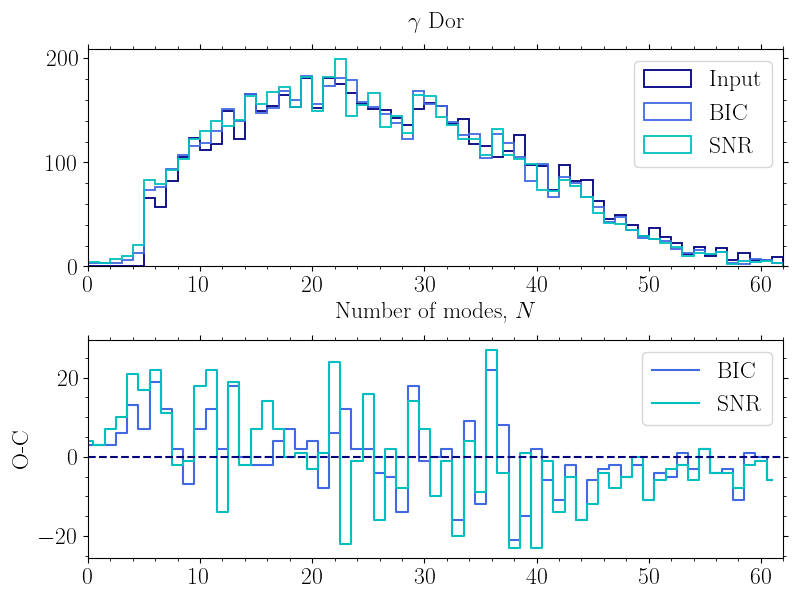

In [301]:
# Histograms
panels = 2
fig, ax = plt.subplots(panels, 1, figsize=(8, 3*panels))

ax[0].hist(dx.N_input, bins=N, range=(0, N), histtype='step', density=False, lw=1.3, ec='navy', label='Input')
ax[0].hist(dx.N_bic,   bins=N, range=(0, N), histtype='step', density=False, lw=1.3, ec='royalblue', label='BIC')
ax[0].hist(dx.N_snr,   bins=N, range=(0, N), histtype='step', density=False, lw=1.3, ec='c', label='SNR')
ax[0].set_xlabel(r'Number of modes, $N$')

ax[1].plot(range(0, N), N_oc_bic, '-', drawstyle='steps-mid', c='royalblue', label='BIC')
ax[1].plot(range(0, N), N_oc_snr, '-', drawstyle='steps-mid', c='c', label='SNR')
ax[1].plot([0, N], [0, 0], '--', c='navy')
ax[1].set_ylabel('O-C')

ax[0].set_title(r'$\gamma$ Dor', pad=15)
for i in range(panels): 
    ax[i].set_xlim(0, N)
    ax[i].legend(loc='best')
plt.tight_layout(pad=0.5);

# Save figure
# fig.savefig(f'{fdir}/hist_parameters_dsct.png', bbox_inches='tight', dpi=200)

In [303]:
N = 150
f_max = np.max(df_bic.freq)

count_input, bin_input = np.histogram(dm.freq,     bins=N, range=(0, f_max))
count_bic, bin_bic     = np.histogram(df_bic.freq, bins=N, range=(0, f_max))
count_snr, bin_snr     = np.histogram(df_snr.freq, bins=N, range=(0, f_max))

f_oc_bic = count_bic / count_input * 100
f_oc_snr = count_snr / count_input * 100

<IPython.core.display.Javascript object>


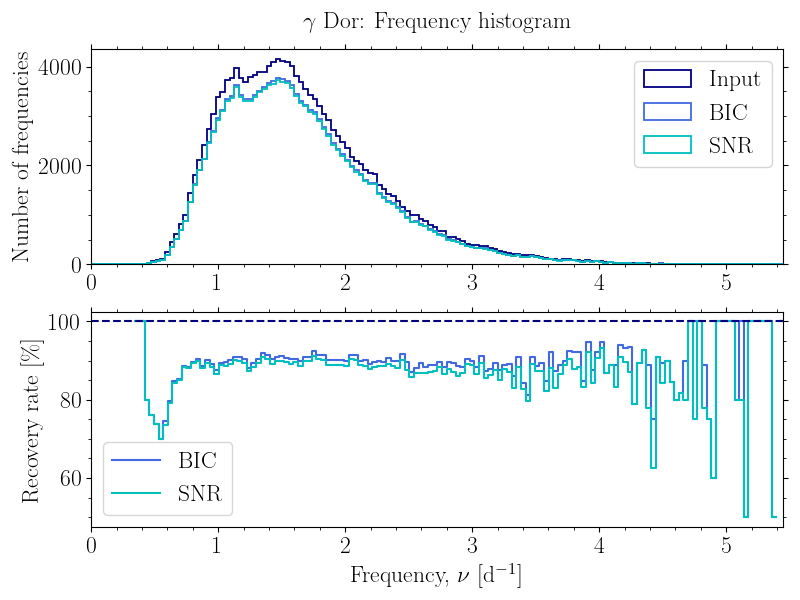

In [306]:
# Histograms
panels = 2
fig, ax = plt.subplots(panels, 1, figsize=(8, 3*panels))

ax[0].hist(dm.freq,     bins=N, range=(0, f_max), histtype='step', density=False, lw=1.3, ec='navy', label='Input')
ax[0].hist(df_bic.freq, bins=N, range=(0, f_max), histtype='step', density=False, lw=1.3, ec='royalblue', label='BIC')
ax[0].hist(df_snr.freq, bins=N, range=(0, f_max), histtype='step', density=False, lw=1.3, ec='c', label='SNR')
ax[0].set_ylabel('Number of frequencies')
# ax[0].set_yscale('log')

ax[1].plot(np.linspace(0, f_max, N), f_oc_bic, '-', drawstyle='steps-mid', c='royalblue', label='BIC')
ax[1].plot(np.linspace(0, f_max, N), f_oc_snr, '-', drawstyle='steps-mid', c='c', label='SNR')
ax[1].plot([0, N], [100, 100], '--', c='navy')
ax[1].set_ylabel('Recovery rate [\%]')
ax[1].set_xlabel(r'Frequency, $\nu$ [d$^{-1}$]')


ax[0].set_title(r'$\gamma$ Dor: Frequency histogram', pad=15)
for i in range(panels): 
    ax[i].set_xlim(0, f_max)
    ax[i].legend(loc='best')
plt.tight_layout(pad=0.5);

# Save figure
# fig.savefig(f'{fdir}/hist_parameters_dsct.png', bbox_inches='tight', dpi=200)

In [277]:
N = 150
A = (10**(0.4*dm.ampl) - 1) * 1e6
A_bic = df_bic.ampl / 2.2
A_max = np.max(A_bic)

count_input, bin_input = np.histogram(A,     bins=N, range=(0, A_max))
count_bic, bin_bic     = np.histogram(A_bic, bins=N, range=(0, A_max))

A_oc_bic = count_bic / count_input * 100

<IPython.core.display.Javascript object>


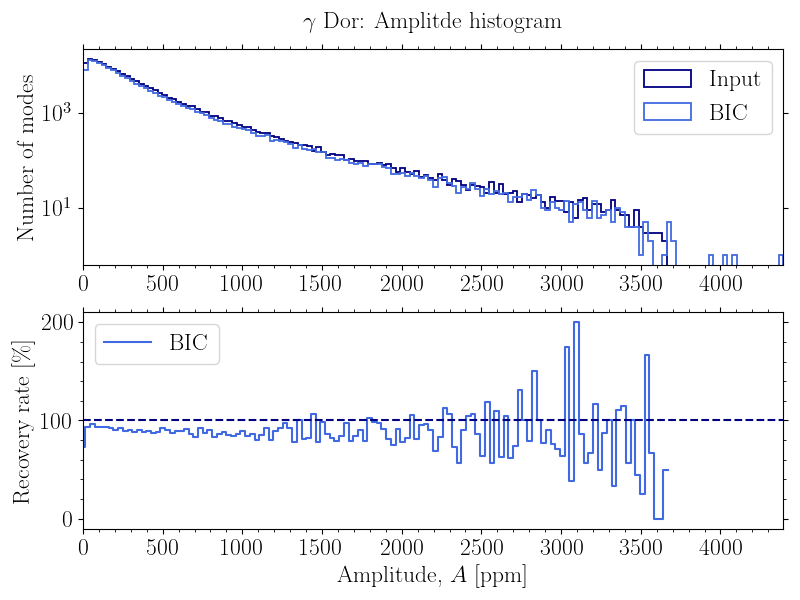

In [296]:
# Histograms
panels = 2
fig, ax = plt.subplots(panels, 1, figsize=(8, 3*panels))

ax[0].hist(A,     bins=N, range=(0, np.max(A_max)), histtype='step', density=False, lw=1.3, ec='navy', label='Input')
ax[0].hist(A_bic, bins=N, range=(0, A_max), histtype='step', density=False, lw=1.3, ec='royalblue', label='BIC')
ax[0].set_ylabel('Number of modes')
ax[0].set_yscale('log')

ax[1].plot(np.linspace(0, A_max, N), A_oc_bic, '-', drawstyle='steps-mid', c='royalblue', label='BIC')
ax[1].plot([0, A_max], [100, 100], '--', c='navy')
ax[1].set_ylabel('Recovery rate [\%]')
ax[1].set_xlabel(r'Amplitude, $A$ [ppm]')

ax[0].set_title(r'$\gamma$ Dor: Amplitde histogram', pad=15)
for i in range(panels): 
    ax[i].set_xlim(0, A_max)
    ax[i].legend(loc='best')
plt.tight_layout(pad=0.5);

# Save figure
# fig.savefig(f'{fdir}/hist_parameters_dsct.png', bbox_inches='tight', dpi=200)

In [308]:
dx

,Pmag,ncam,SPR,A_limit,N_input,N_bic,N_snr,f_rms_bic,f_rms_snr,A_rms_bic,A_rms_snr
0,13.936833,48,0.237099,69.492107,16,13,12,142.318578,146.945071,176.625406,183.791569
0,11.653350,48,0.012636,100.939423,13,13,13,62.222713,62.222713,932.962042,932.962042
0,10.915871,48,0.110751,24.756166,14,14,14,24.969989,24.969989,167.484357,167.484357
0,11.040159,48,0.009698,17.846253,40,40,39,49.185739,32.829419,322.318999,326.420967
0,12.522381,48,0.011275,50.687950,37,35,35,79.709035,79.709035,654.023346,654.023346
...,...,...,...,...,...,...,...,...,...,...,...
0,12.315666,192,0.000000,51.273929,20,19,19,110.786652,110.786652,328.287498,328.287498
0,11.721022,192,0.173305,11.683579,8,8,7,47.365968,16.514202,99.251125,106.099979
0,9.312771,192,0.775785,NaN,7,0,0,NaN,NaN,NaN,NaN
0,15.545957,192,0.000000,49.281538,22,22,22,43.379862,43.379862,742.919242,742.919242


In [377]:
from scipy.ndimage import median_filter

dx = dx.sort_values(by=['Pmag', 'ncam']).dropna()

A_limit_med = median_filter(dx.A_limit, 1000)
A_rms_med   = median_filter(dx.A_rms_snr, 1000)
f_rms_med   = median_filter(dx.f_rms_snr, 1000)

dx06 = dx[dx.ncam == 48]
dx12 = dx[dx.ncam == 96]
dx18 = dx[dx.ncam == 144]
dx24 = dx[dx.ncam == 192]

A_limit_med06 = median_filter(dx06.A_limit, 1000)
A_limit_med12 = median_filter(dx12.A_limit, 1000)
A_limit_med18 = median_filter(dx18.A_limit, 1000)
A_limit_med24 = median_filter(dx24.A_limit, 1000)

A_rms_med06 = median_filter(dx06.A_rms_snr, 1000)
A_rms_med12 = median_filter(dx12.A_rms_snr, 1000)
A_rms_med18 = median_filter(dx18.A_rms_snr, 1000)
A_rms_med24 = median_filter(dx24.A_rms_snr, 1000)

<IPython.core.display.Javascript object>


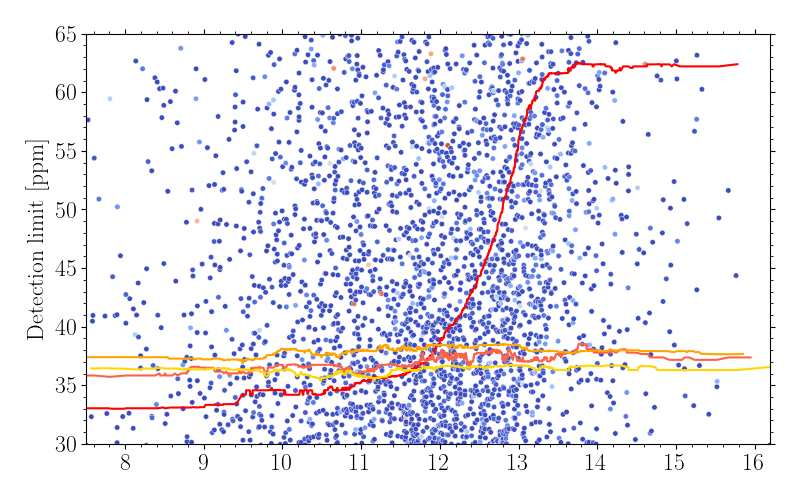

In [376]:
# Histograms
fig, ax = plt.subplots(1, 1, figsize=(8, 5*panels))
ax.scatter(dx.Pmag, dx.A_limit, c=dx.SPR, marker='o', s=15, linewidth=0.3, edgecolor='w', cmap="coolwarm")
ax.plot(dx06.Pmag, A_limit_med06, '-', lw=1.5, c='r')
ax.plot(dx12.Pmag, A_limit_med12, '-', lw=1.5, c='tomato')
ax.plot(dx18.Pmag, A_limit_med18, '-', lw=1.5, c='orange')
ax.plot(dx24.Pmag, A_limit_med24, '-', lw=1.5, c='gold')
ax.set_ylabel('Detection limit [ppm]')
ax.set_xlim(dx.Pmag.min(), dx.Pmag.max())
ax.set_ylim(30, 65)
plt.tight_layout();

<IPython.core.display.Javascript object>


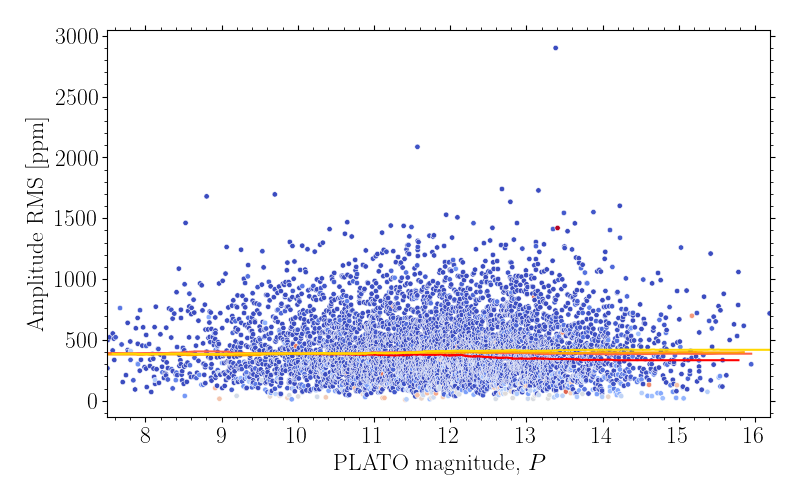

In [382]:
# Histograms
fig, ax = plt.subplots(1, 1, figsize=(8, 5*panels))
ax.scatter(dx.Pmag, dx.A_rms_snr, c=dx.SPR, marker='o', s=15, linewidth=0.4, edgecolor='w', cmap="coolwarm")
ax.plot(dx06.Pmag, A_rms_med06, '-', lw=1.5, c='r')
ax.plot(dx12.Pmag, A_rms_med12, '-', lw=1.5, c='tomato')
ax.plot(dx18.Pmag, A_rms_med18, '-', lw=1.5, c='orange')
ax.plot(dx24.Pmag, A_rms_med24, '-', lw=1.5, c='gold')
ax.set_ylabel('Amplitude RMS [ppm]')
ax.set_xlabel(r'PLATO magnitude, $P$')
ax.set_xlim(dx.Pmag.min(), dx.Pmag.max())
# ax.set_ylim(300, 450)
plt.tight_layout();

<IPython.core.display.Javascript object>


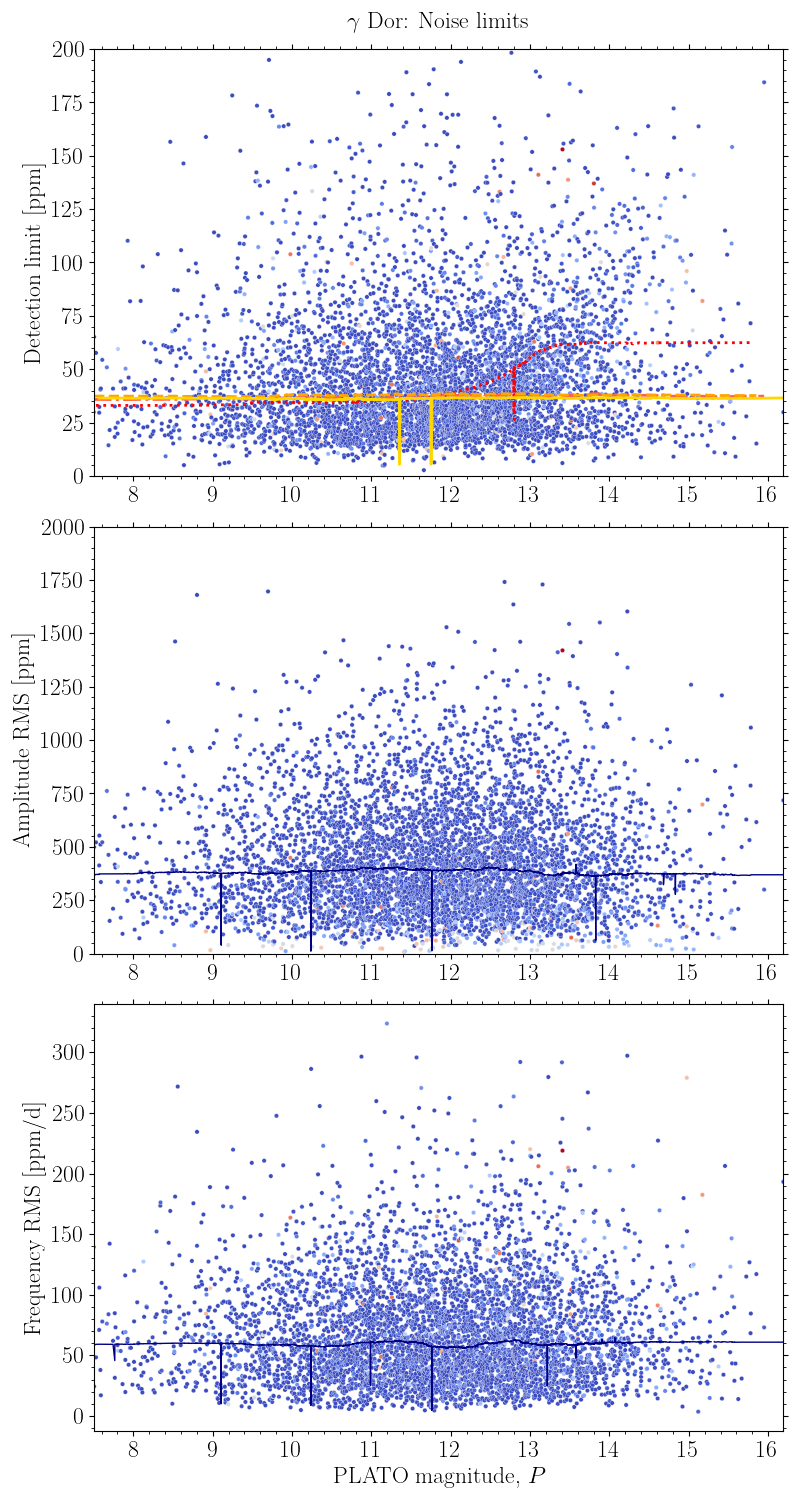

In [362]:

# Histograms
panels = 3
fig, ax = plt.subplots(panels, 1, figsize=(8, 5*panels))

ax[0].scatter(dx.Pmag, dx.A_limit, c=dx.SPR, marker='o', s=10, linewidth=0.2, edgecolor='w', cmap="coolwarm")
# ax[0].plot(dx.Pmag, A_limit_med, '-', c='navy',   lw=1.0)
ax[0].plot(dx06.Pmag, A_limit_med06, ':',  lw=2.0, c='r')
ax[0].plot(dx12.Pmag, A_limit_med12, '-.', lw=2.0, c='tomato')
ax[0].plot(dx18.Pmag, A_limit_med18, '--', lw=2.0, c='orange')
ax[0].plot(dx24.Pmag, A_limit_med24, '-',  lw=2.0, c='gold')
ax[0].set_ylabel('Detection limit [ppm]')
ax[0].set_ylim(0, 200)
# cmap="viridis"

ax[1].scatter(dx.Pmag, dx.A_rms_snr, c=dx.SPR, marker='o', s=10, linewidth=0.2, edgecolor='w', cmap="coolwarm")
# ax[1].plot(dx.Pmag, dx.A_rms_snr, '.', c='orange', ms=2, mec='gray', lw=1)
ax[1].plot(dx.Pmag, A_rms_med, '-', c='navy',   lw=1.0)
ax[1].set_ylabel('Amplitude RMS [ppm]')
ax[1].set_ylim(0, 2000)

ax[2].scatter(dx.Pmag, dx.f_rms_snr, c=dx.SPR, marker='o', s=10, linewidth=0.2, edgecolor='w', cmap="coolwarm")
ax[2].plot(dx.Pmag, f_rms_med, '-', c='navy', lw=1.0)
ax[2].set_ylabel('Frequency RMS [ppm/d]')
ax[2].set_xlabel(r'PLATO magnitude, $P$')

# ax[0].set_yscale('log')

# ax[1].plot(np.linspace(0, A_max, N), A_oc_bic, '-', drawstyle='steps-mid', c='royalblue', label='BIC')
# ax[1].plot([0, A_max], [100, 100], '--', c='navy')
# ax[1].set_ylabel('Recovery rate [\%]')
# ax[1].set_xlabel(r'Amplitude, $A$ [ppm]')

ax[0].set_title(r'$\gamma$ Dor: Noise limits', pad=15)
for i in range(panels): 
    ax[i].set_xlim(dx.Pmag.min(), dx.Pmag.max())
#     ax[i].legend(loc='best')
plt.tight_layout(pad=0.5);